<a href="https://colab.research.google.com/github/Vinith-15116/ML-File/blob/main/Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [4]:
#UPLOAD DATASET
headers = ["symboling","normalized-losses","make","fuel-type","aspiration", "num-of-doors","body-style",
         "drive-wheels","engine-location","wheel-base", "length","width","height","curb-weight","engine-type",
         "num-of-cylinders", "engine-size","fuel-system","bore","stroke","compression-ratio","horsepower",
         "peak-rpm","city-mpg","highway-mpg","price"]

df = pd.read_csv('/content/car_dataset.data',names=headers)

In [5]:
#LOAD DATASET
print("Original Data:")
print(df.head())

Original Data:
   symboling normalized-losses         make fuel-type aspiration num-of-doors  \
0          3                 ?  alfa-romero       gas        std          two   
1          3                 ?  alfa-romero       gas        std          two   
2          1                 ?  alfa-romero       gas        std          two   
3          2               164         audi       gas        std         four   
4          2               164         audi       gas        std         four   

    body-style drive-wheels engine-location  wheel-base  ...  engine-size  \
0  convertible          rwd           front        88.6  ...          130   
1  convertible          rwd           front        88.6  ...          130   
2    hatchback          rwd           front        94.5  ...          152   
3        sedan          fwd           front        99.8  ...          109   
4        sedan          4wd           front        99.4  ...          136   

   fuel-system  bore  stroke compre

In [6]:
# 4. EDA
print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  205 non-null    object 
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-of-doors       205 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-of-cylinders   205 non-null    object 
 16  engine-size

In [12]:
# 5. DATA PREPROCESSING
df.replace("-", np.nan, inplace=True)
df.replace(" ", np.nan, inplace=True)
df.replace("", np.nan, inplace=True)

num_cols = ["normalized-losses","bore","stroke","horsepower","peak-rpm","price"]
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

for col in num_cols:
    df[col] = df[col].fillna(df[col].mean())

cat_cols = df.select_dtypes(include='object').columns
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

df.dropna(subset=["price"], inplace=True)

In [13]:
# 6. CREATE TARGET (CLASSIFICATION)
# Convert price into 0/1
df["price_class"] = (df["price"] > df["price"].median()).astype(int)

print("\nClass Distribution:")
print(df["price_class"].value_counts())


Class Distribution:
price_class
0    103
1    102
Name: count, dtype: int64


In [15]:
# 7. FEATURE SCALING
X = df.drop(["price", "price_class"], axis=1)
y = df["price_class"]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [16]:
# 8. TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2)

In [17]:
# 9. MODEL TRAINING
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [18]:
# 10. PREDICTION
y_pred = model.predict(X_test)

In [19]:
# 11. EVALUATION
print("\nMODEL PERFORMANCE")
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))



MODEL PERFORMANCE
Accuracy: 0.8780487804878049

Confusion Matrix:
 [[17  3]
 [ 2 19]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.85      0.87        20
           1       0.86      0.90      0.88        21

    accuracy                           0.88        41
   macro avg       0.88      0.88      0.88        41
weighted avg       0.88      0.88      0.88        41



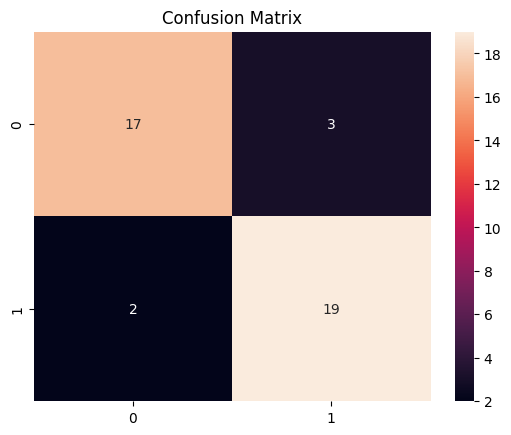

In [20]:
# 12. VISUALIZATION
plt.figure()
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [25]:
# MANUAL INPUT (YOUR FORMAT)

new_car = [[
    4,127,0,1,0,1,2,1,0,100,175,66,54,2600,
    2,3,135,1,4.5,2.9,8.5,115,5500,26,35
]]

new_car_df = pd.DataFrame(new_car, columns=X.columns)

print("Input Data:")
print(new_car_df)

# Apply scaling
new_car_scaled = scaler.transform(new_car_df)

# Predict class
prediction = model.predict(new_car_scaled)

# Predict probability
probability = model.predict_proba(new_car_scaled)

print("\nPredicted Class (0=Low Price, 1=High Price):", prediction[0])
print("Probability [Low, High]:", probability[0])

Input Data:
   symboling  normalized-losses  make  fuel-type  aspiration  num-of-doors  \
0          4                127     0          1           0             1   

   body-style  drive-wheels  engine-location  wheel-base  ...  \
0           2             1                0         100  ...   

   num-of-cylinders  engine-size  fuel-system  bore  stroke  \
0                 3          135            1   4.5     2.9   

   compression-ratio  horsepower  peak-rpm  city-mpg  highway-mpg  
0                8.5         115      5500        26           35  

[1 rows x 25 columns]

Predicted Class (0=Low Price, 1=High Price): 1
Probability [Low, High]: [0.00288149 0.99711851]
